In [56]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine

OUTPUT_FOLDER = Path("/home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output")

### Section 1: Load and Merge CSVs

In [57]:
df_spoof = pd.read_csv(f"{OUTPUT_FOLDER}/tcav_dev_A09_bonafide.csv")
df_bonafide = pd.read_csv(f"{OUTPUT_FOLDER}/tcav_dev_A09.csv")

df = pd.concat([df_spoof, df_bonafide], ignore_index=True)
df.head()   

,system_id,source_partition,split,speaker_id,magnitude,sign_count,concept_name,target_class
0,A09,dev,test,ALL_SELECTED,0.102034,0.5900,long_constant_thick,bonafide
1,A09,dev,test,ALL_SELECTED,0.261580,0.6825,long_dropping_flat_thick,bonafide
2,A09,dev,test,ALL_SELECTED,0.121503,0.5925,long_dropping_steep_thick,bonafide
3,A09,dev,test,ALL_SELECTED,0.224965,0.6675,long_dropping_steep_thin,bonafide
4,A09,dev,test,ALL_SELECTED,0.295186,0.7100,long_rising_flat_thick,bonafide


### Section 2: Side-by-Side Comparison

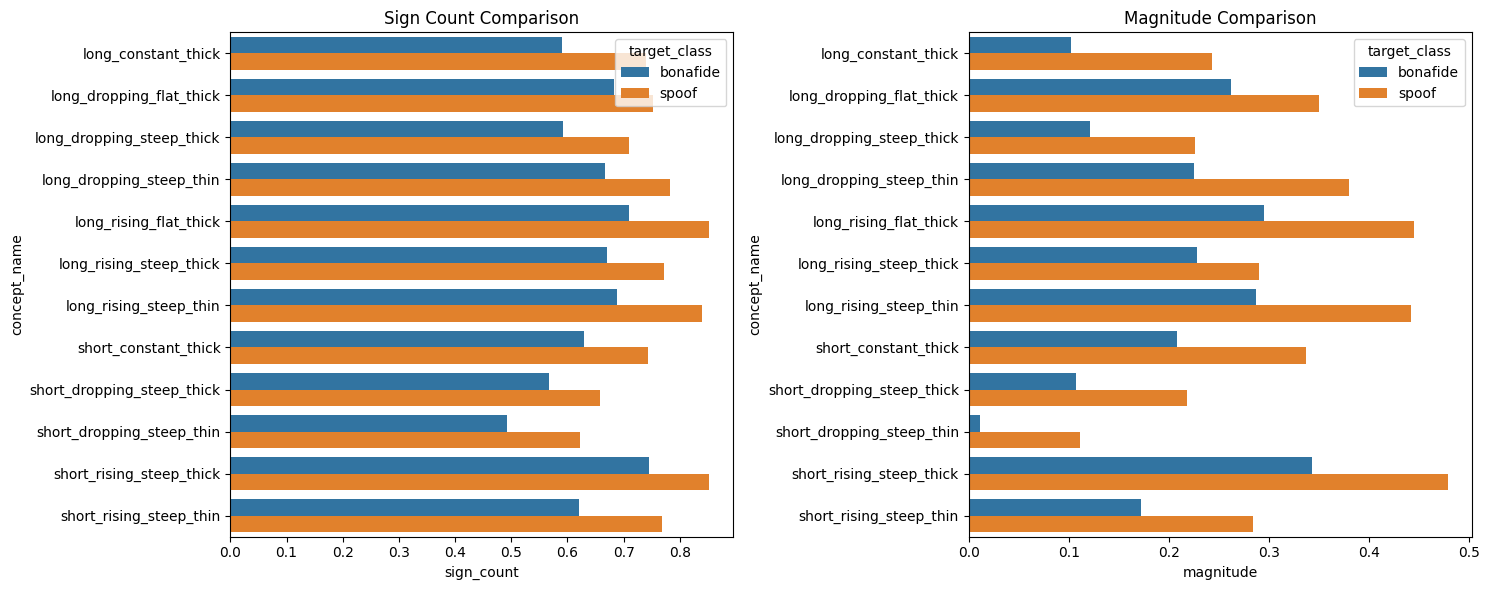

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=df, x="sign_count", y="concept_name", hue="target_class", ax=axes[0])
axes[0].set_title("Sign Count Comparison")

sns.barplot(data=df, x="magnitude", y="concept_name", hue="target_class", ax=axes[1])
axes[1].set_title("Magnitude Comparison")

plt.tight_layout()
plt.show()

### Section 3: Concept Vectors and Cosine Similarity

In [59]:
v_spoof_sc = df_spoof.sort_values("concept_name")["sign_count"].values
v_bonafide_sc = df_bonafide.sort_values("concept_name")["sign_count"].values
cos_sim_sc = 1 - cosine(v_spoof_sc, v_bonafide_sc)

v_spoof_centered = v_spoof_sc * 2 - 1
v_bonafide_centered = v_bonafide_sc * 2 - 1
cos_sim_centered = 1 - cosine(v_spoof_centered, v_bonafide_centered)

v_spoof_mag = df_spoof.sort_values("concept_name")["magnitude"].values
v_bonafide_mag = df_bonafide.sort_values("concept_name")["magnitude"].values
cos_sim_mag = 1 - cosine(v_spoof_mag, v_bonafide_mag)

print(f"Cosine Similarity (sign_count raw [0,1]):     {cos_sim_sc:.4f}")
print(f"Cosine Similarity (sign_count centered [-1,+1]): {cos_sim_centered:.4f}")
print(f"Cosine Similarity (magnitude):                {cos_sim_mag:.4f}")

Cosine Similarity (sign_count raw [0,1]):     0.9993
Cosine Similarity (sign_count centered [-1,+1]): 0.9744
Cosine Similarity (magnitude):                0.9882


### Section 4: Per-Concept Deltas and Ranking

In [60]:
df_merged = df_spoof.merge(df_bonafide, on="concept_name", suffixes=("_spoof", "_bonafide"))
df_merged["delta_sign_count"] = df_merged["sign_count_spoof"] - df_merged["sign_count_bonafide"]
df_merged["delta_magnitude"] = df_merged["magnitude_spoof"] - df_merged["magnitude_bonafide"]
df_merged["abs_delta_sign"] = df_merged["delta_sign_count"].abs()

print("Concepts that stayed the same (small delta):")
print(df_merged.nsmallest(3, "abs_delta_sign")[["concept_name", "delta_sign_count"]])

print("\nConcepts that changed the most (large delta):")
print(df_merged.nlargest(3, "abs_delta_sign")[["concept_name", "delta_sign_count"]])

print("\nConcepts where magnitude sign flipped (if any):")
flipped = df_merged[np.sign(df_merged["magnitude_spoof"]) != np.sign(df_merged["magnitude_bonafide"])]
print(flipped[["concept_name", "magnitude_spoof", "magnitude_bonafide"]])

Concepts that stayed the same (small delta):
                 concept_name  delta_sign_count
1    long_dropping_flat_thick           -0.0700
8  short_dropping_steep_thick           -0.0900
5     long_rising_steep_thick           -0.1025

Concepts that changed the most (large delta):
               concept_name  delta_sign_count
6    long_rising_steep_thin           -0.1525
0       long_constant_thick           -0.1500
11  short_rising_steep_thin           -0.1475

Concepts where magnitude sign flipped (if any):
Empty DataFrame
Columns: [concept_name, magnitude_spoof, magnitude_bonafide]
Index: []


### Section 5: Shared vs Distinctive Concepts

In [61]:
threshold = 0.7
df_merged["is_strong_spoof"] = df_merged["sign_count_spoof"] > threshold
df_merged["is_strong_bonafide"] = df_merged["sign_count_bonafide"] > threshold

shared = df_merged[df_merged["is_strong_spoof"] & df_merged["is_strong_bonafide"]]
distinctive = df_merged[df_merged["is_strong_spoof"] ^ df_merged["is_strong_bonafide"]]

print(f"Shared strong concepts (> {threshold}):")
print(shared["concept_name"].tolist())

print(f"\nDistinctive concepts (> {threshold} in only one):")
print(distinctive["concept_name"].tolist())

Shared strong concepts (> 0.7):
['long_rising_flat_thick', 'short_rising_steep_thick']

Distinctive concepts (> 0.7 in only one):
['long_constant_thick', 'long_dropping_flat_thick', 'long_dropping_steep_thick', 'long_dropping_steep_thin', 'long_rising_steep_thick', 'long_rising_steep_thin', 'short_constant_thick', 'short_rising_steep_thin']


### Section 6: Diverging Delta Chart and Summary

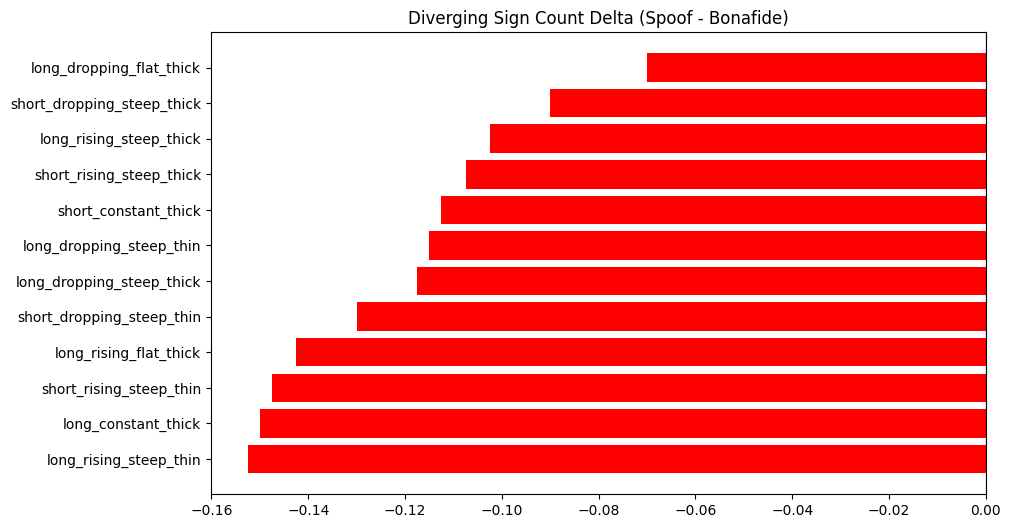

--- Summary ---
Cosine Similarity (sign_count raw):      0.9993
Cosine Similarity (sign_count centered):  0.9744
Cosine Similarity (magnitude):            0.9882
Top Preserved: long_dropping_flat_thick
Top Changed: long_rising_steep_thin


In [62]:
plt.figure(figsize=(10, 6))
df_merged = df_merged.sort_values("delta_sign_count")
colors = ["red" if x < 0 else "green" for x in df_merged["delta_sign_count"]]
plt.barh(df_merged["concept_name"], df_merged["delta_sign_count"], color=colors)
plt.title("Diverging Sign Count Delta (Spoof - Bonafide)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

print("--- Summary ---")
print(f"Cosine Similarity (sign_count raw):      {cos_sim_sc:.4f}")
print(f"Cosine Similarity (sign_count centered):  {cos_sim_centered:.4f}")
print(f"Cosine Similarity (magnitude):            {cos_sim_mag:.4f}")
print(f"Top Preserved: {df_merged.nsmallest(1, 'abs_delta_sign')['concept_name'].values[0]}")
print(f"Top Changed: {df_merged.nlargest(1, 'abs_delta_sign')['concept_name'].values[0]}")